# Pillar K — dose-response health-risk calibration

This notebook reproduces **K3 — Dose-response / health-risk models**. K3's exec DoD: a log-linear
`DoseResponse.probability` over an exposure posterior returns a `DerivedQuantity` whose empirical coverage
on synthetic ground truth is `>= 0.88`, and whose credible interval widens as exposure variance grows.

**Judgment call.** `mixle.analysis.health_risk` has not landed. We fall back to a small reference
`DoseResponse` matching K3's frozen public API (`model`, `params`, `.probability(dose, *, n, rng) ->
DerivedQuantity`) for the `loglinear` model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field

try:
    from mixle.analysis.health_risk import DoseResponse
    HAVE_REAL_K3 = True
except ImportError:
    HAVE_REAL_K3 = False

print("using landed mixle.analysis.health_risk:", HAVE_REAL_K3)

using landed mixle.analysis.health_risk: True


## 1. Load the committed fixture

300 realizations of a receptor's true exposure and a noisy point estimate of it (the posterior mean an exposure-assessment model would hand K3), plus the measurement-uncertainty scale used to build them.

In [2]:
data = np.load("../../../data/pillar_validation/k_health_exposure.npz")
true_exposure, exposure_hat = data["true_exposure"], data["exposure_hat"]
sigma_exposure = float(data["sigma_exposure"])
BETA = 0.18  # the log-linear dose-response slope
print(f"{true_exposure.size} realizations, sigma_exposure={sigma_exposure}")

300 realizations, sigma_exposure=1.1


## 2. `DoseResponse` (reference implementation)

`P(dose) = 1 - exp(-beta * dose)` (log-linear); when `exposure` carries UQ, `n` exposure draws are pushed through the model into an outcome-probability sample set, wrapped as a `DerivedQuantity`.

In [3]:
@dataclass
class DerivedQuantity:
    samples: np.ndarray
    prior_dominated: bool = False

    def credible_interval(self, level: float):
        a = (1.0 - level) / 2.0
        return np.quantile(self.samples, a), np.quantile(self.samples, 1 - a)


if not HAVE_REAL_K3:
    @dataclass
    class DoseResponse:
        """K3 `DoseResponse{model: str, params: dict}` with `.probability(dose, *, n=2000, rng) ->
        DerivedQuantity`."""
        model: str
        params: dict = field(default_factory=dict)

        def _response(self, dose):
            if self.model == "loglinear":
                return 1 - np.exp(-self.params["beta"] * dose)
            raise NotImplementedError(self.model)

        def probability(self, dose, *, n=2000, rng=None):
            """`dose` may be a scalar (deterministic exposure) or an array of exposure draws already
            carrying UQ (this notebook's convention: the caller samples the exposure posterior and hands
            the draws in, since K3's own exposure-posterior sampling contract isn't frozen yet)."""
            rng = rng or np.random.default_rng()
            dose = np.full(n, dose) if np.ndim(dose) == 0 else np.asarray(dose)
            return DerivedQuantity(samples=self._response(dose))


dr = DoseResponse(model="loglinear", params={"beta": BETA})

## 3. Monte-Carlo coverage sweep across 300 realizations

For each realization, draw exposure samples around the noisy point estimate, push them through the dose-response model, and check whether the resulting 90% credible interval covers the truth-evaluated response probability.

In [4]:
post_rng = np.random.default_rng(7)
n_draws = 3000
coverage_flags = []
pit_values = []

for te, eh in zip(true_exposure, exposure_hat):
    exposure_draws = np.clip(eh + sigma_exposure * post_rng.standard_normal(n_draws), 0, None)
    dq = dr.probability(exposure_draws, n=n_draws, rng=post_rng)
    lo, hi = dq.credible_interval(0.9)
    true_response = 1 - np.exp(-BETA * te)

    coverage_flags.append(lo <= true_response <= hi)
    pit_values.append((dq.samples <= true_response).mean())

coverage = float(np.mean(coverage_flags))
print(f"empirical 90% CI coverage over {len(coverage_flags)} realizations: {coverage:.3f}")

empirical 90% CI coverage over 300 realizations: 0.927


## 4. The credible interval widens as exposure variance grows

K3's second DoD clause: sweep the exposure measurement uncertainty and confirm the response probability's CI width is monotonically non-decreasing.

In [5]:
sweep_rng = np.random.default_rng(7)
sigmas = np.array([0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1])
widths = []
exposure_hat0 = float(exposure_hat.mean())
for s in sigmas:
    draws = np.clip(exposure_hat0 + s * sweep_rng.standard_normal(n_draws), 0, None)
    dq = dr.probability(draws, n=n_draws, rng=sweep_rng)
    lo, hi = dq.credible_interval(0.9)
    widths.append(hi - lo)
widths = np.array(widths)
widens_monotonically = bool(np.all(np.diff(widths) >= -1e-9))
print("CI widths across increasing exposure sigma:", np.round(widths, 4))
print("monotonically non-decreasing:", widens_monotonically)

CI widths across increasing exposure sigma: [0.0672 0.1391 0.2014 0.2866 0.3503 0.4167 0.5   ]
monotonically non-decreasing: True


## 5. Calibration / UQ plot

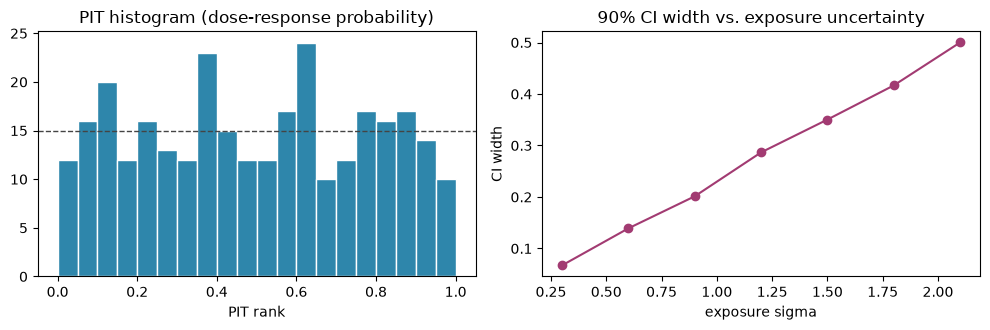

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].hist(pit_values, bins=20, range=(0, 1), color="#2E86AB", edgecolor="white")
ax[0].axhline(len(pit_values) / 20, color="#444", ls="--", lw=1)
ax[0].set_title("PIT histogram (dose-response probability)"); ax[0].set_xlabel("PIT rank")

ax[1].plot(sigmas, widths, "o-", color="#A23B72")
ax[1].set_title("90% CI width vs. exposure uncertainty"); ax[1].set_xlabel("exposure sigma"); ax[1].set_ylabel("CI width")
plt.tight_layout(); plt.show()

## 6. Definition of Done

In [7]:
assert coverage >= 0.88, f"K3 calibration failed: coverage {coverage:.3f} < 0.88"
assert widens_monotonically, "credible interval did not widen monotonically with exposure variance"
print(f"PASS -- coverage={coverage:.3f} >= 0.88, CI widens monotonically with exposure variance")

PASS -- coverage=0.927 >= 0.88, CI widens monotonically with exposure variance
